In [1]:
import os
tex_path = '/dss/dsshome1/07/go69lir/texlive/2026/bin/x86_64-linux' # Example path
if tex_path not in os.environ['PATH']:
    os.environ['PATH'] += os.pathsep + tex_path

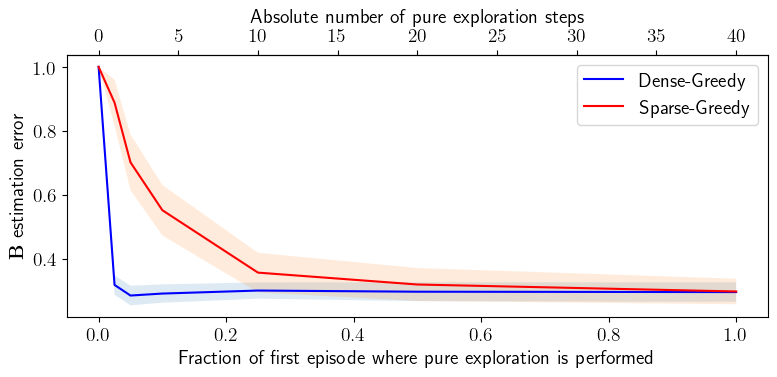

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import json

plt.rcParams.update({
    "font.size": 14,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "text.usetex": True,
})

paths = {
    0.0: "d10_m_explore0.0/20260604_180520",
    0.025: "d10_m_explore0.025/20260604_180508",
    0.05: "d10_m_explore0.05/20260604_180454",
    0.1: "d10_m_explore0.1/20260604_180440",
    0.25: "d10_m_explore0.25/20260604_180426",
    0.5: "d10_m_explore0.5/20260604_180411",
    1.0: "d10_m_explore1.0/20260604_180358"
}

data = {
    agent: {
        "regret_mean": [],
        "regret_ci": []
    } for agent in ["dense_greedy", "sparse_greedy"]
}
for m_explore, path in paths.items():
    with open(f'../results/sweeps/{path}/results.json') as f:
        config = json.load(f)
        for agent in ["dense_greedy", "sparse_greedy"]:
            data[agent]["regret_mean"].append(config["summary"][agent]["error_B"][0])
            data[agent]["regret_ci"].append(config["summary"][agent]["error_B"][1])

plt.figure(figsize=(8, 4))
for a in ["dense", "sparse"]:
    mean = np.array(data[f"{a}_greedy"]["regret_mean"])
    ci = np.array(data[f"{a}_greedy"]["regret_ci"])
    colour = "blue" if a == "dense" else "red"
    plt.plot(paths.keys(), mean, label=f'{a.capitalize()}-Greedy', color=colour)
    plt.fill_between(paths.keys(), mean - ci, mean + ci, alpha=0.15)

plt.gca().secondary_xaxis('top', functions=(lambda x: x * 40, lambda x: x / 40)).set_xlabel("Absolute number of pure exploration steps")
plt.xlabel("Fraction of first episode where pure exploration is performed")
plt.ylabel("$\mathbf{B}$ estimation error")
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('pure_exploration.pdf', dpi=300, bbox_inches='tight')
plt.savefig('pure_exploration.pdf', dpi=300, bbox_inches='tight')